# This is a simple example of how to load and plot the provided data.

In [1]:
import zarr
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
# Load the data (update the path to the correct location)
data_path = "../data/cse151b-spring2025-competition/processed_data_cse151b_v2_corrupted_ssp245/processed_data_cse151b_v2_corrupted_ssp245.zarr"
data = xr.open_zarr(data_path)
data

<xarray.Dataset> Size: 621MB
Dimensions:    (ssp: 4, time: 1021, latitude: 48, longitude: 72, x: 72, y: 48,
                member_id: 3)
Coordinates:
    lat        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * latitude   (latitude) float64 384B -89.05 -85.26 -81.47 ... 85.26 89.05
    lon        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * longitude  (longitude) float64 576B 1.25 6.25 11.25 ... 346.2 351.2 356.2
  * member_id  (member_id) int64 24B 0 1 2
  * ssp        (ssp) <U6 96B 'ssp126' 'ssp245' 'ssp370' 'ssp585'
  * time       (time) object 8kB 2015-01-15 00:00:00 ... 2100-01-15 00:00:00
  * x          (x) float64 576B 1.875 6.875 11.88 16.88 ... 346.9 351.9 356.9
  * y          (y) float64 384B -88.59 -84.82 -81.05 ... 81.05 84.82 88.59
Data variables:
    BC         (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    CH4        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
    CO2        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
    SO2        (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    pr         (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
    rsdt       (ssp, time, y, x) float32 56MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    tas        (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
Attributes:
    original_member_ids:  ['r10i1p1f1', 'r11i1p1f1', 'r4i1p1f1']
    precipitation_units:  mm/day (converted from kg m-2 s-1)
    source:               CMIP6 data processed for CSE151B
    ssp:                  ssp126

In [12]:
data.coords['lat'].values

array([[-88.58638743, -84.81675393, -81.04712042, ...,  81.04712042,
         84.81675393,  88.58638743],
       [-88.58638743, -84.81675393, -81.04712042, ...,  81.04712042,
         84.81675393,  88.58638743],
       [-88.58638743, -84.81675393, -81.04712042, ...,  81.04712042,
         84.81675393,  88.58638743],
       ...,
       [-88.58638743, -84.81675393, -81.04712042, ...,  81.04712042,
         84.81675393,  88.58638743],
       [-88.58638743, -84.81675393, -81.04712042, ...,  81.04712042,
         84.81675393,  88.58638743],
       [-88.58638743, -84.81675393, -81.04712042, ...,  81.04712042,
         84.81675393,  88.58638743]], shape=(72, 48))

## Plot a few snapshots of temperature and precipitation (first, middle, and last)

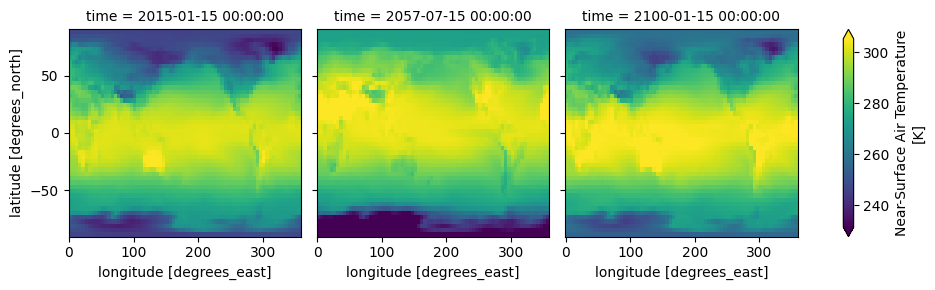

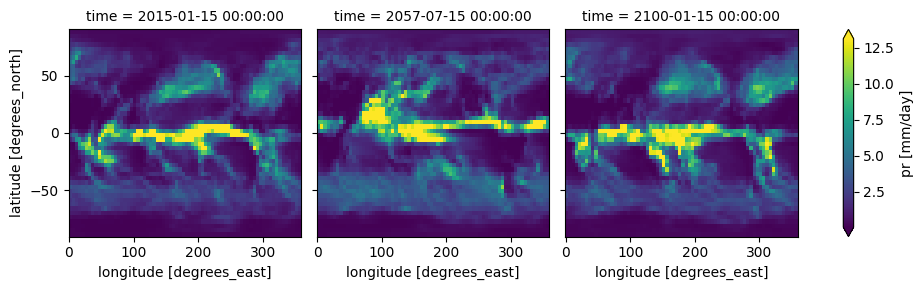

In [3]:
data_subset = data.isel(time=[0, data.time.size // 2, -1]).sel(ssp="ssp370", member_id=0)
data_subset.tas.plot(col="time", x="x", y="y", robust=True)
data_subset.pr.plot(col="time", x="x", y="y", robust=True)

# Plot the time series of global mean temperature and precipitation

Note that we do not plot the SSP245 scenario here, as it is corrupted in the provided data.

zsh:1: 1.2.0 not found
Note: you may need to restart the kernel to use updated packages.


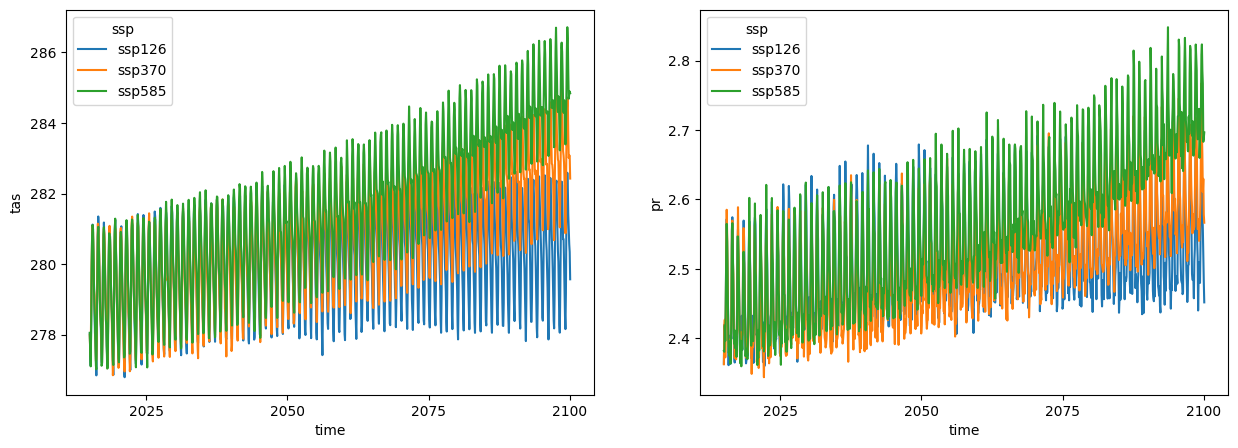

In [4]:
%pip install nc-time-axis>=1.2.0
global_mean_data = data.sel(ssp=["ssp126", "ssp370", "ssp585"]).mean(dim=["x", "y", "member_id"])  # also average over all ensemble members
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
global_mean_data.tas.plot(label="Temperature", ax=ax[0], hue="ssp")
global_mean_data.pr.plot(label="Precipitation", ax=ax[1], hue="ssp")# Plot the time series of global mean temperature and precipitation

# Plot the (global mean) time series of climate forcings

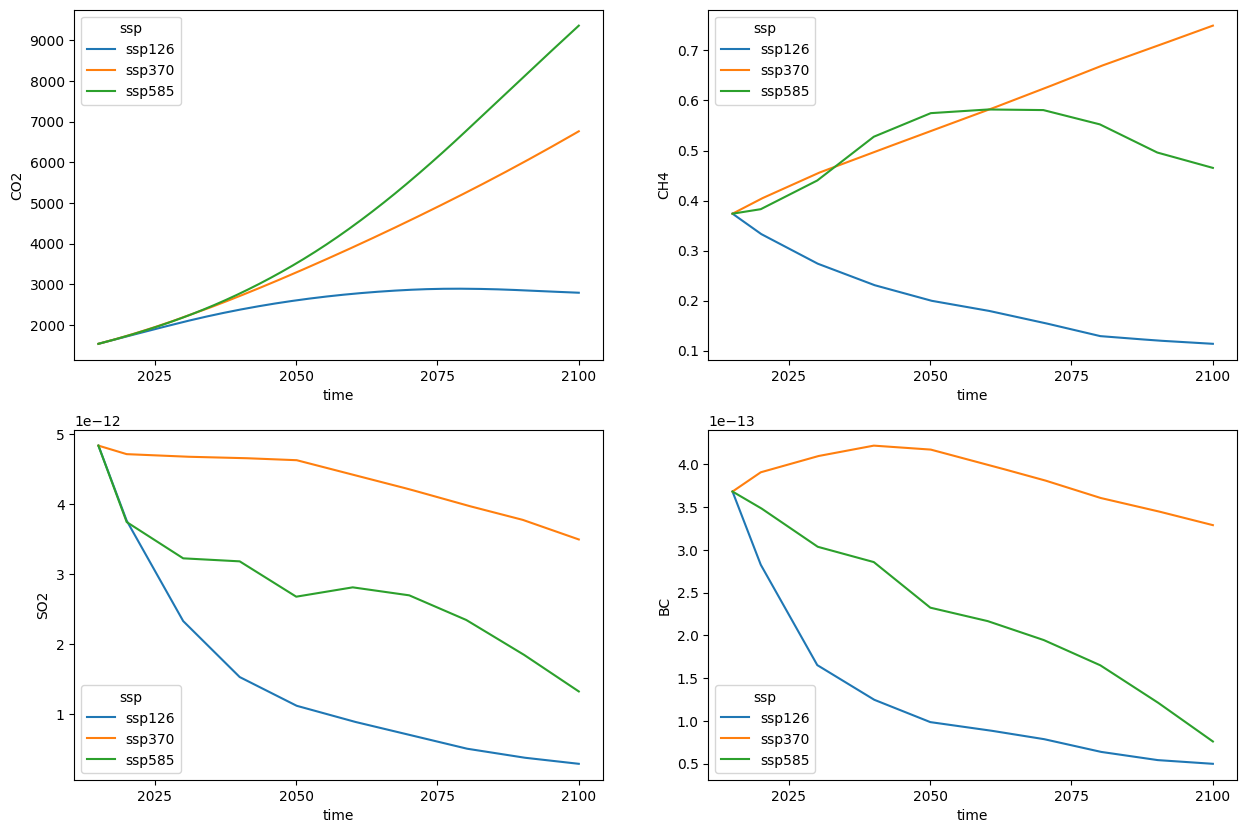

In [5]:
global_mean_data = data.sel(ssp=["ssp126", "ssp370", "ssp585"]).mean(dim=["longitude", "latitude", "member_id"]) 
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
global_mean_data.CO2.plot(ax=axes[0], hue="ssp")
global_mean_data.CH4.plot(ax=axes[1], hue="ssp")
global_mean_data.SO2.plot(ax=axes[2], hue="ssp")
_ = global_mean_data.BC.plot(ax=axes[3], hue="ssp")

# Distribution of pr and tas

/var/folders/g9/2_h1fx2n71s3vx71bqdn2vl40000gn/T/ipykernel_76922/74363945.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/g9/2_h1fx2n71s3vx71bqdn2vl40000gn/T/ipykernel_76922/74363945.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


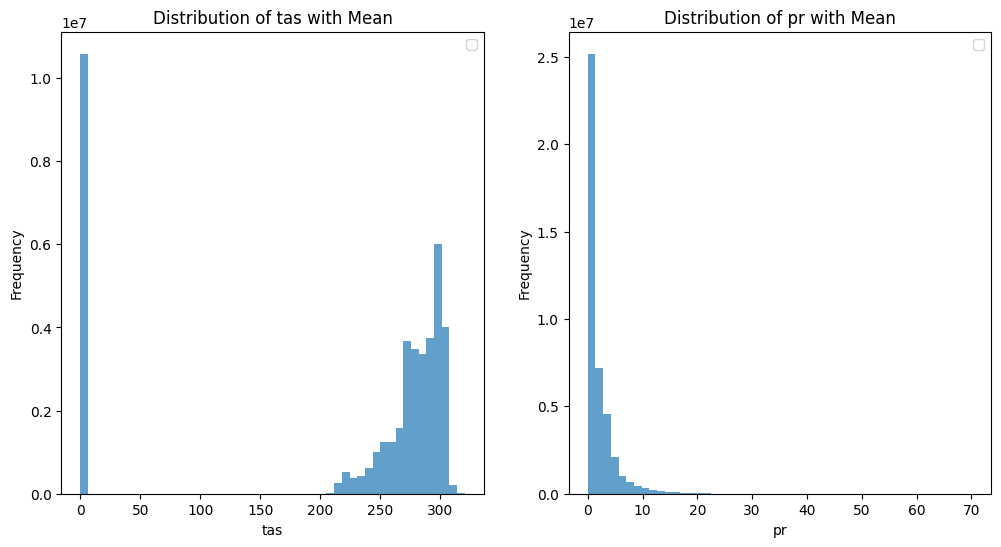

In [17]:
import numpy as np

# Flatten tas and pr arrays, and compute the mean

# Flatten tas values
tas_values = data['tas'].values.flatten()

# Flatten pr values
pr_values = data['pr'].values.flatten()

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(tas_values, bins=50, alpha=0.7)
plt.xlabel('tas')
plt.ylabel('Frequency')
plt.title('Distribution of tas with Mean')
plt.legend()

plt.subplot(1,2,2)
plt.hist(pr_values, bins=50, alpha=0.7)
plt.xlabel('pr')
plt.ylabel('Frequency')
plt.title('Distribution of pr with Mean')
plt.legend()

plt.show()


Values:  [1536.07222245 1539.1156809  1541.86461111 ... 2793.49360367 2793.02362297
 2792.53797625]
Values:  [1536.07222245 1539.18885562 1542.00387912 ... 6750.47680158 6757.05819516
 6763.85896852]
Values:  [1536.07222245 1539.16887221 1541.96584619 ... 9341.23191372 9351.73762728
 9362.5935313 ]
Values:  [0.37373672 0.37305323 0.37243588 ... 0.11375656 0.11370178 0.11364518]
Values:  [0.37373672 0.3742375  0.37468982 ... 0.74892031 0.74925746 0.74960585]
Values:  [0.37373672 0.37388976 0.37402798 ... 0.46577208 0.46551541 0.4652502 ]


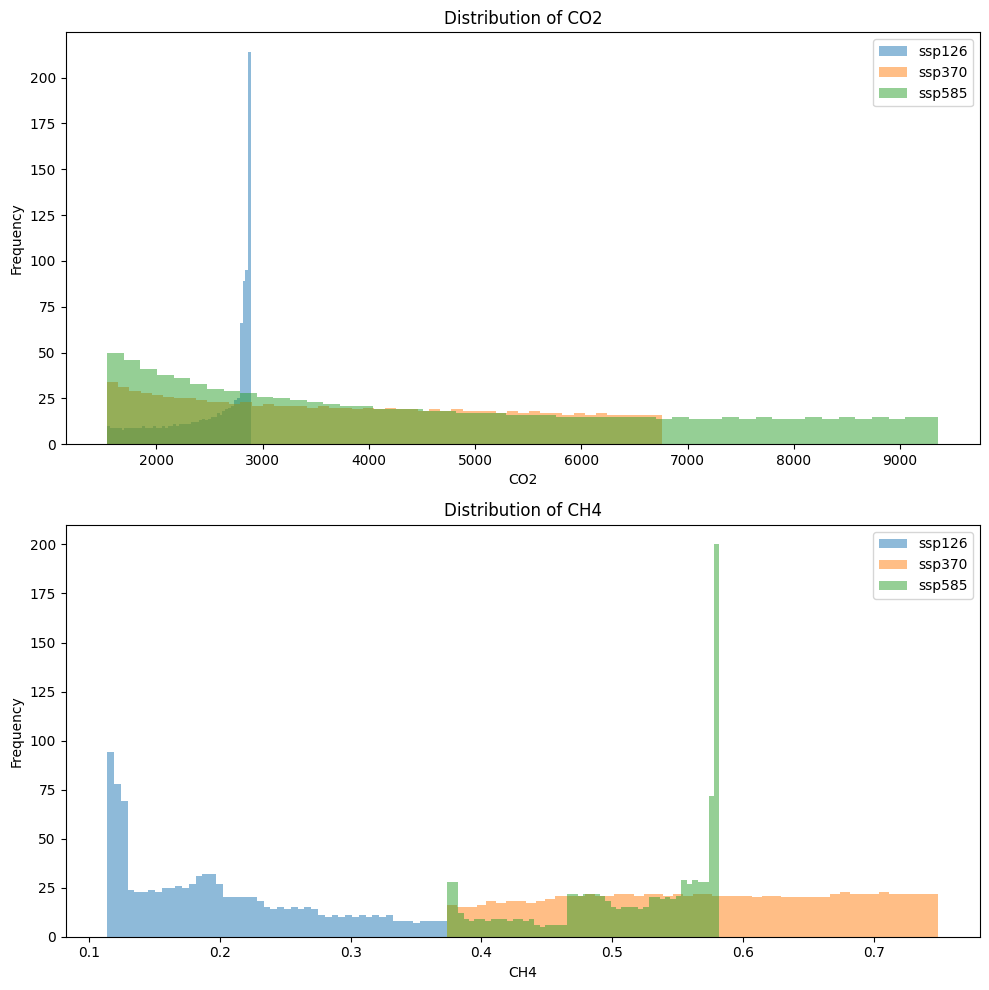

In [37]:
scenarios = ['ssp126', 'ssp370', 'ssp585']
variables = ['CO2', 'CH4']

fig, axs = plt.subplots(nrows=len(variables), ncols=1, figsize=(10, 5 * len(variables)))
if len(variables) == 1:
  axs = [axs]

for ax, var in zip(axs, variables):
  for ssp in scenarios:
    # Select the data for given scenario, flatten the values, and compute histogram
    values = data[var].sel(ssp=ssp).values.flatten()
    print("Values: ", values)
    ax.hist(values, bins=50, alpha=0.5, label=ssp)
  ax.set_title(f"Distribution of {var}")
  ax.set_xlabel(var)
  ax.set_ylabel("Frequency")
  ax.legend()

plt.tight_layout()
plt.show()

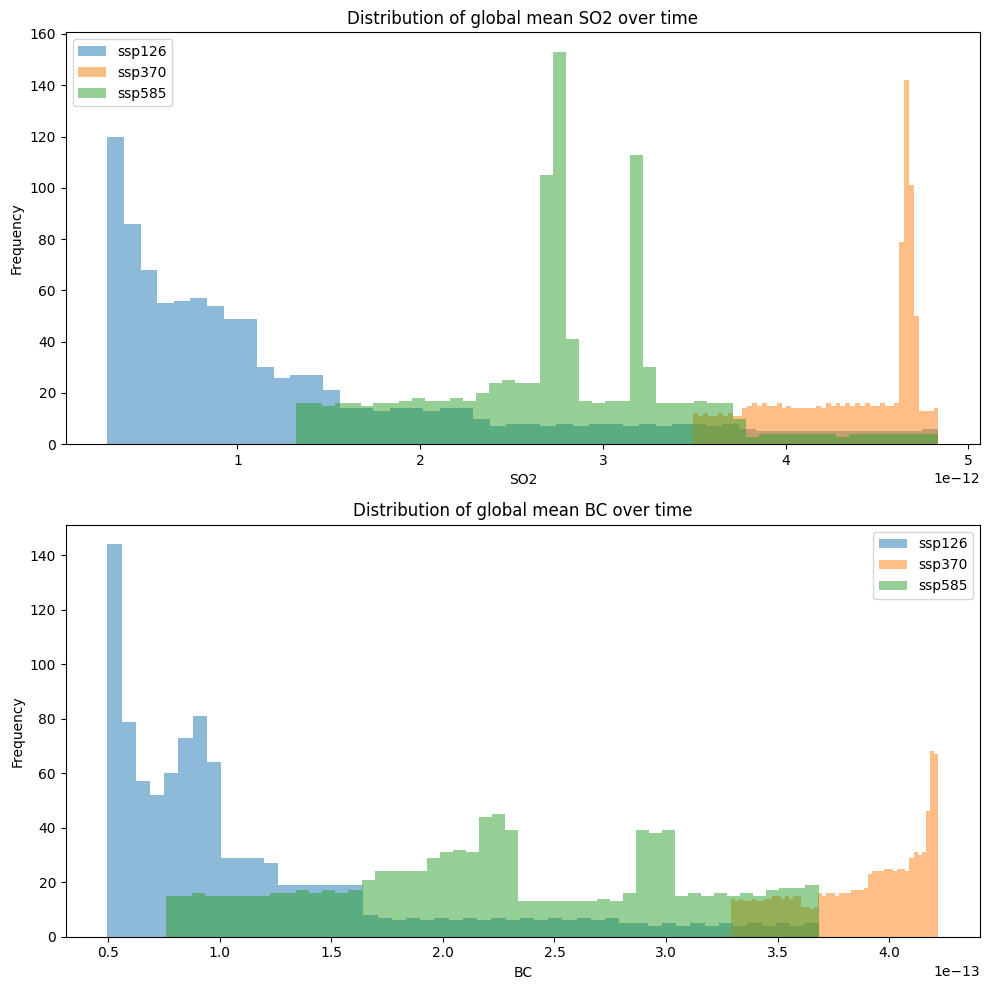

In [38]:
variables = ['SO2', 'BC']
# use the same SSP scenarios as in previous plots
scenarios = ['ssp126', 'ssp370', 'ssp585']

fig, axs = plt.subplots(nrows=len(variables), figsize=(10, 5*len(variables)))
if len(variables) == 1:
  axs = [axs]

for ax, var in zip(axs, variables):
  for ssp in scenarios:
    # Compute the global mean (average over latitude and longitude) for each timestep
    global_mean = data[var].sel(ssp=ssp).mean(dim=["latitude", "longitude"]).values
    ax.hist(global_mean, bins=50, alpha=0.5, label=ssp)
  ax.set_title(f"Distribution of global mean {var} over time")
  ax.set_xlabel(var)
  ax.set_ylabel("Frequency")
  ax.legend()

plt.tight_layout()
plt.show()

In [20]:
data.time.values

array([cftime.DatetimeNoLeap(2015, 1, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2015, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2015, 3, 15, 0, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeNoLeap(2099, 11, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2099, 12, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2100, 1, 15, 0, 0, 0, 0, has_year_zero=True)],
      shape=(1021,), dtype=object)

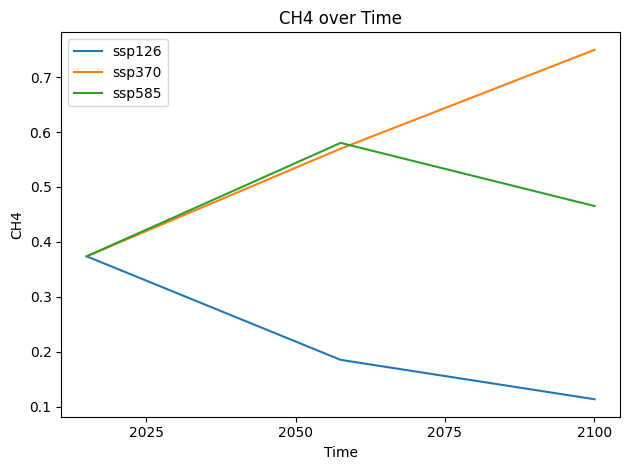

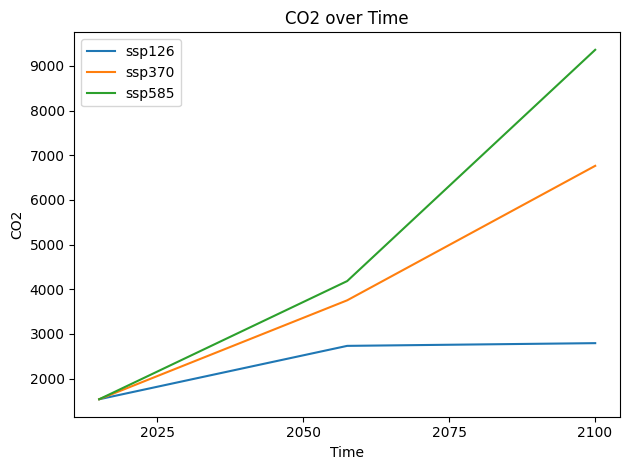

In [25]:
scenarios = ['ssp126', 'ssp370', 'ssp585']

# Plot CH4 over time for all scenarios on one figure
plt.figure()
for ssp in scenarios:
  data_subset = data.isel(time=[0, data.time.size // 2, -1]).sel(ssp=ssp, member_id=0)
  times = data_subset['time'].values
  plt.plot(times, data_subset['CH4'].values, label=ssp)
plt.title('CH4 over Time')
plt.xlabel('Time')
plt.ylabel('CH4')
plt.legend()
plt.tight_layout()
plt.show()

# Plot CO2 over time for all scenarios on one figure
plt.figure()
for ssp in scenarios:
  data_subset = data.isel(time=[0, data.time.size // 2, -1]).sel(ssp=ssp, member_id=0)
  times = data_subset['time'].values
  plt.plot(times, data_subset['CO2'].values, label=ssp)
plt.title('CO2 over Time')
plt.xlabel('Time')
plt.ylabel('CO2')
plt.legend()
plt.tight_layout()
plt.show()

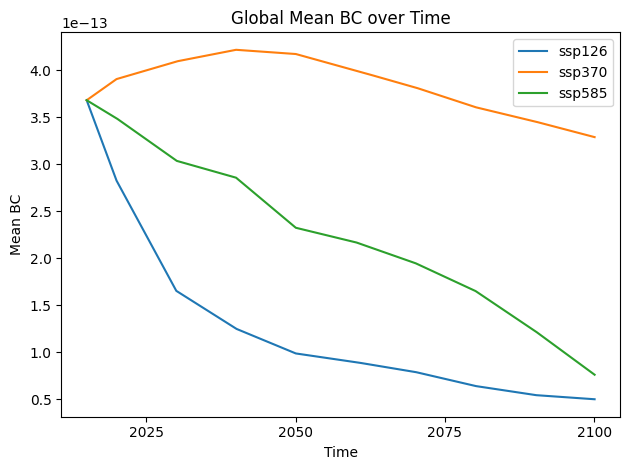

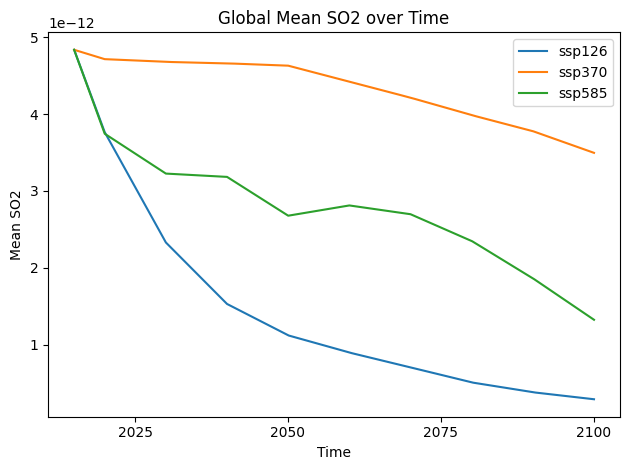

In [39]:
# Plot CH4 over time for all scenarios on one figure
global_mean_BC = data.BC.mean(dim=["latitude", "longitude"])
global_mean_SO2 = data.SO2.mean(dim=["latitude", "longitude"])

plt.figure()
for ssp in scenarios:
  plt.plot(data.time, global_mean_BC.sel(ssp=ssp), label=ssp)
plt.title("Global Mean BC over Time")
plt.xlabel("Time")
plt.ylabel("Mean BC")
plt.legend()
plt.tight_layout()

plt.figure()
for ssp in scenarios:
  plt.plot(data.time, global_mean_SO2.sel(ssp=ssp), label=ssp)
plt.title("Global Mean SO2 over Time")
plt.xlabel("Time")
plt.ylabel("Mean SO2")
plt.legend()
plt.tight_layout()
plt.show()

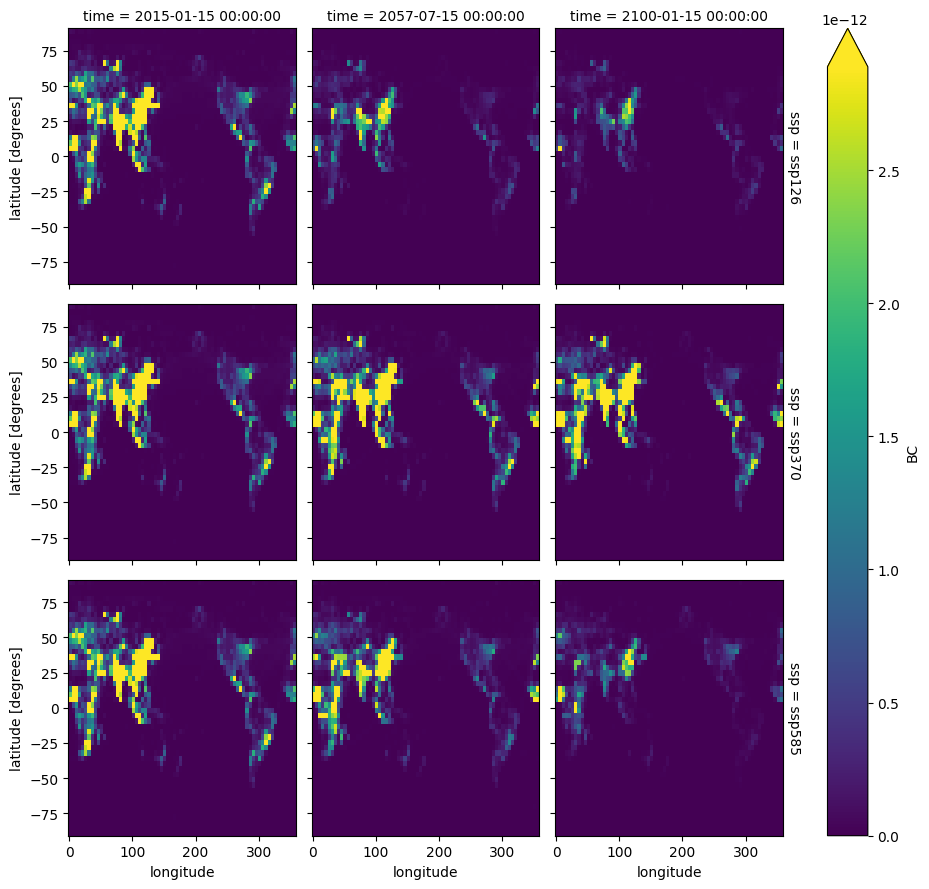

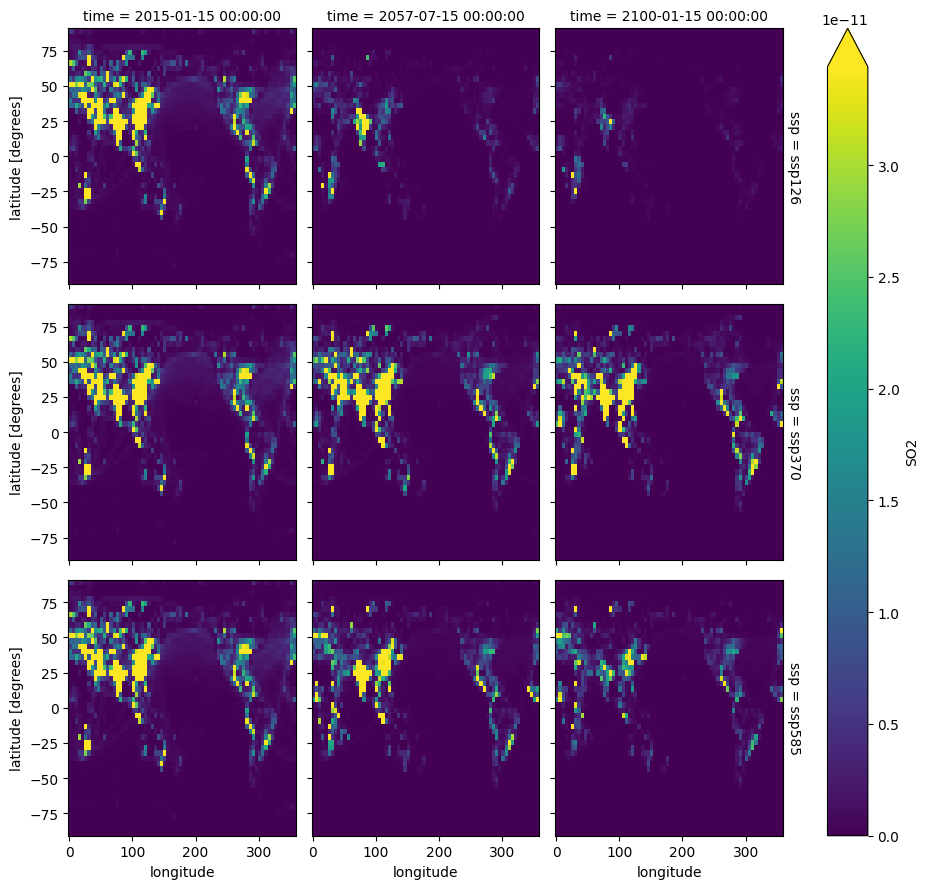

In [31]:
data_subset = data.isel(time=[0, data.time.size // 2, -1]).sel(ssp=['ssp126', 'ssp370', 'ssp585'], member_id=0)
data_subset.BC.plot(row="ssp", col="time", x="longitude", y="latitude", robust=True)
data_subset.SO2.plot(row="ssp", col="time", x="longitude", y="latitude", robust=True)

In [32]:
print(data.sel(ssp=['ssp126', 'ssp370', 'ssp585']))

<xarray.Dataset> Size: 466MB
Dimensions:    (ssp: 3, time: 1021, latitude: 48, longitude: 72, x: 72, y: 48,
                member_id: 3)
Coordinates:
    lat        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * latitude   (latitude) float64 384B -89.05 -85.26 -81.47 ... 85.26 89.05
    lon        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * longitude  (longitude) float64 576B 1.25 6.25 11.25 ... 346.2 351.2 356.2
  * member_id  (member_id) int64 24B 0 1 2
  * ssp        (ssp) <U6 72B 'ssp126' 'ssp370' 'ssp585'
  * time       (time) object 8kB 2015-01-15 00:00:00 ... 2100-01-15 00:00:00
  * x          (x) float64 576B 1.875 6.875 11.88 16.88 ... 346.9 351.9 356.9
  * y          (y) float64 384B -88.59 -84.82 -81.05 ... 81.05 84.82 88.59
Data variables:
    BC         (ssp, time, latitude, longitude) float64 85MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    CH4        (ssp, time) float64 25kB dask.array<chunksize=(1, 24)

In [33]:
print(data.sel(ssp='ssp245'))

<xarray.Dataset> Size: 155MB
Dimensions:    (time: 1021, latitude: 48, longitude: 72, x: 72, y: 48,
                member_id: 3)
Coordinates:
    lat        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * latitude   (latitude) float64 384B -89.05 -85.26 -81.47 ... 85.26 89.05
    lon        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * longitude  (longitude) float64 576B 1.25 6.25 11.25 ... 346.2 351.2 356.2
  * member_id  (member_id) int64 24B 0 1 2
    ssp        <U6 24B 'ssp245'
  * time       (time) object 8kB 2015-01-15 00:00:00 ... 2100-01-15 00:00:00
  * x          (x) float64 576B 1.875 6.875 11.88 16.88 ... 346.9 351.9 356.9
  * y          (y) float64 384B -88.59 -84.82 -81.05 ... 81.05 84.82 88.59
Data variables:
    BC         (time, latitude, longitude) float64 28MB dask.array<chunksize=(24, 48, 72), meta=np.ndarray>
    CH4        (time) float64 8kB dask.array<chunksize=(24,), meta=np.ndarray>
    CO2        (time) float64